# ViT Inference: Load Trained Model + Test on Real Photos

Small, focused notebook, only loads the trained ViT (checkpoint
`best_model_vit.pt`, produced by `04A_vit_finetuning_colab.ipynb`) and runs
predictions on real photos. No training code mixed in, mirrors the
structure of `03B_cnn_inference.ipynb` for the CNN.

**Run the cells in order, top to bottom, every time you open a new
session.**

## 0. Environment setup

In [1]:
#  ENVIRONMENT SETUP
RUNTIME = "colab"     # "colab" or "local"
DEVICE  = "auto"      # "auto", "gpu", or "cpu"

In [2]:
import torch

if RUNTIME == "colab":
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q transformers

    PROJECT_ROOT = "/content/drive/MyDrive/CNN/wardrove-selector"
elif RUNTIME == "local":
    PROJECT_ROOT = ".."
else:
    raise ValueError(f"Unknown RUNTIME: {RUNTIME!r} (expected 'colab' or 'local')")

import sys
sys.path.append(f"{PROJECT_ROOT}/src")

if DEVICE == "auto":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
elif DEVICE == "gpu":
    if not torch.cuda.is_available():
        raise RuntimeError("DEVICE='gpu' was requested but no GPU is available in this runtime.")
    device = torch.device('cuda')
elif DEVICE == "cpu":
    device = torch.device('cpu')
else:
    raise ValueError(f"Unknown DEVICE: {DEVICE!r} (expected 'auto', 'gpu', or 'cpu')")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"device       = {device}")

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/CNN/wardrove-selector
device       = cpu


## 1. Load the architecture

In [3]:
!pip install -q transformers

from transformers import AutoImageProcessor, AutoModelForImageClassification

checkpoint = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(checkpoint)
model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=14,
    ignore_mismatched_sizes=True   # head gets reinitialized random here, that's why step 2 is required
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=14` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([14, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([14])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## 2. Load the trained weights (required step, do not skip)

The previous step leaves `model.classifier` with **random** weights (not
trained), this cell loads the real fine-tuned weights. Skip it and
predictions will be essentially random, with no recognizable pattern.

In [4]:
model.load_state_dict(torch.load(
    f"{PROJECT_ROOT}/notebooks/best_model_vit.pt",
    map_location=device   # important: checkpoint was saved on GPU, this loads it correctly even on CPU
))
model = model.to(device)
model.eval()

print("Checkpoint loaded, model ready on:", device)

Checkpoint loaded, model ready on: cpu


## 3. Categories

Imported from `src/data.py` (same fixed order used everywhere else in the
project), must match, since the model's output index N means "class N
in this exact list".

In [5]:
from data import categories

## 4. Prediction function

Uses `processor` (not `transforms.Resize`+`ToTensor` by hand), same
preprocessing the model was trained with. Using different preprocessing
here was the bug that caused nonsense predictions early on (tshirt →
shoes). See `04A` for the full story.

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

def image_predict_vit(image, filename=""):
    pixel_values = processor(image, return_tensors="pt")["pixel_values"]

    with torch.no_grad():
        logits = model(pixel_values.to(device)).logits
        pred = torch.argmax(logits, dim=1)

    print(f"{filename}: {categories[pred.item()]}")

    plt.imshow(image)
    plt.axis('off')
    plt.show()

## 5. Run over every photo in `data/my_photos/`

Automatically picks up every `.jpg`/`.JPG` in the folder, no need to list
filenames by hand.

Found 10 photos
photo_01.jpg: Dresses


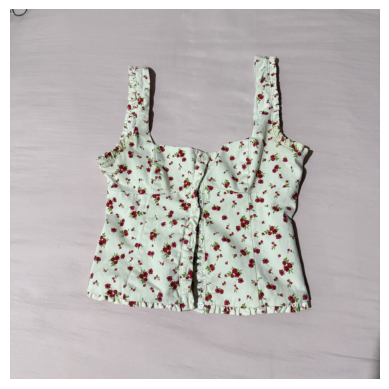

photo_02.jpg: Tops


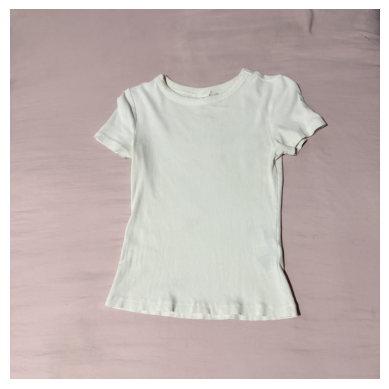

photo_03.jpg: Jeans


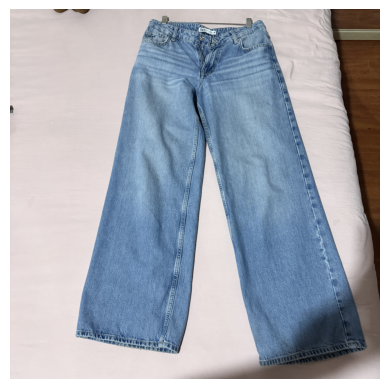

photo_04.jpg: Skirts


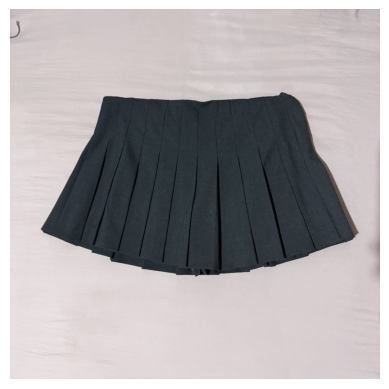

photo_05.jpg: Shorts


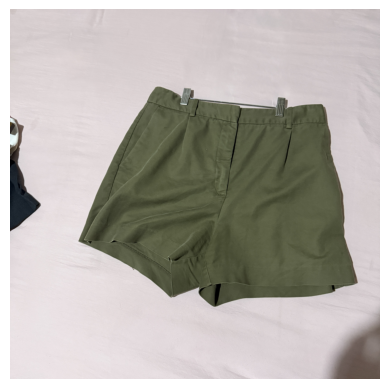

photo_G01.jpg: Dresses


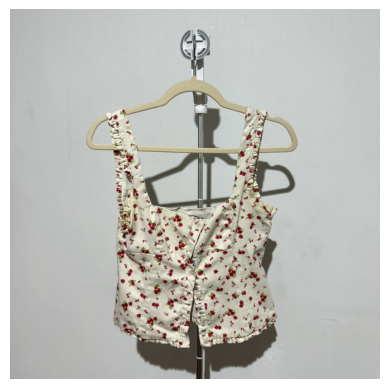

photo_G02.jpg: Tshirts


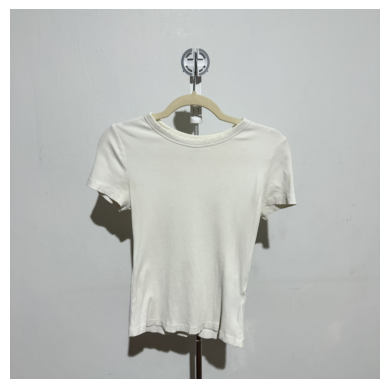

photo_G03.jpg: Jeans


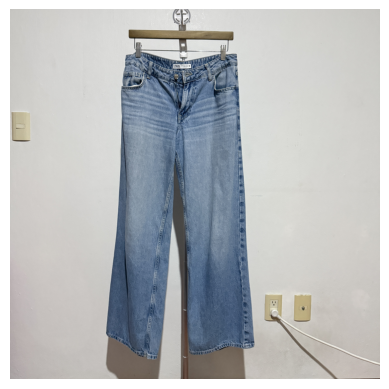

photo_G04.jpg: Skirts


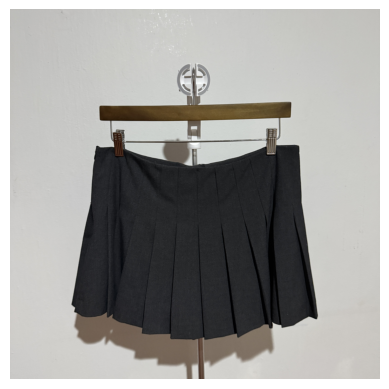

photo_G05.jpg: Shorts


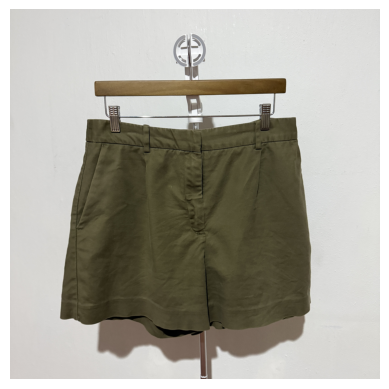

In [7]:
from pathlib import Path

photos_dir = Path(f"{PROJECT_ROOT}/data/my_photos")
photo_paths = sorted(photos_dir.glob("*.jpg")) + sorted(photos_dir.glob("*.JPG"))

print(f"Found {len(photo_paths)} photos")

for path in photo_paths:
    image = Image.open(path).convert("RGB")
    image_predict_vit(image, filename=path.name)